# Perceptron: Fashion-MNIST Classification

A project from my postgraduate course *Deep Learning and Neural Networks*, implementing a Perceptron from scratch (step and sigmoid activations, online and batch learning) and using it to classify Fashion-MNIST images — first as a binary clothing-vs-shoe classifier, then extended to full 10-class classification via a one-vs-all scheme.

See the [main README](./README.md) for a summary of the approach and results.

## Perceptron Implementation

In [18]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron(object):

    #==========================================#
    # The init method is called when an object #
    # is created. It can be used to initialize #
    # the attributes of the class.             #
    #==========================================#
    def __init__(self, no_inputs, activation, max_iterations=20, learning_rate=0.1, label_mode="cloth_vs_shoe", target_class=None):
        self.no_inputs = no_inputs
        self.weights = np.random.uniform(-0.01, 0.01, no_inputs)
        self.max_iter = max_iterations
        self.learning_rate = learning_rate
        self.activation = activation
        self.label_mode = label_mode
        self.target_class = target_class 

    #=======================================#
    # Prints the details of the perceptron. #
    #=======================================#
    def print_details(self):
        print('---------------------------')
        print("No. inputs:\t" + str(self.no_inputs))
        print("Max iterations:\t" + str(self.max_iter))
        print("Learning rate:\t" + str(self.learning_rate))
        print("Activation Function:\t" + str(self.activation))
        print("Classification task:\t" + str(self.label_mode))
        print("Target class:\t" + str(self.target_class))
        print('---------------------------')

    def activate_sigmoid(self, a):
        return 1 / (1 + np.exp(-a))
    
    def activate_step(self, a):
        return np.where(a >= 0, 1, 0)
    
    #=========================================#
    # Performs feed-forward prediction on one #
    # set of inputs.                          #
    #=========================================#
    
    # the prediction needs to take all x values which correspond to a single pixel intensity value.
    # therefore, since each image is a 28x28 image, there will be 784 input values.
    # the prediction will work by taking the weighted sum of the inputs then negating the bias.
    # the output for this part will then be applied to an activation function (either the step or sigmoid) and the output
    # from this determines the classification.
    
    def do_predict(self, x):
        x_with_bias = np.append(x, 1) # adding a 1 to the inputs for the bias
        weighted_sum = np.dot(self.weights, x_with_bias)
        
        if self.activation == 'step':                   # step activation function
            return self.activate_step(weighted_sum)
        elif self.activation == 'sigmoid':              # sigmoid activation function
            return self.activate_sigmoid(weighted_sum)

    #======================================#
    # Trains the perceptron using labelled #
    # training data.                       #
    #======================================#
    
    # Creating a function to fix the labels for a binary classifier
    
    def label_to_binary(self, labels):
        if self.label_mode == "cloth_vs_shoe":
            label_mapping = {
                0: 0,  # T-shirt/top (cloth)
                1: 1,  # Trouser (cloth)
                2: 0,  # Pullover (cloth)
                3: 0,  # Dress (cloth)
                4: 0,  # Coat (cloth)
                5: 0,  # Sandal (shoe)
                6: 0,  # Shirt (cloth)
                7: 0,  # Sneaker (shoe)
                8: 0,  # Bag (cloth)
                9: 0   # Ankle_boot (shoe)
            }
            return [label_mapping[label] for label in labels]

        elif self.label_mode == "one_vs_all":
            if self.target_class is None:
                raise ValueError("target_class must be specified for 'one_vs_all' mode.")
            return [1 if label == self.target_class else 0 for label in labels]

        else:
            raise ValueError("Invalid label_mode. Choose 'cloth_vs_shoe' or 'one_vs_all'.")
        
    # Creating a function that will perform a min max normalization on the input data
        
    def min_max_normalize(self, inputs):
        inputs = np.array(inputs)
        min_vals = np.min(inputs, axis=0)
        max_vals = np.max(inputs, axis=0)
        return (inputs - min_vals) / (max_vals - min_vals)
    
    # creating the training online
    
    def do_train_online(self, training_data, verbose = True):
        
        if verbose:
            print('---------------------------')
            print('Training Perceptron...')
            
            print(f'Training Online using the "{self.activation}" activation function')
        for _ in  range(self.max_iter):
            
            np.random.shuffle(training_data)  # shuffle the data
            for data in training_data:
                # split the data into the labels and inputs
                label = int(data[0])
                binary_label = self.label_to_binary([label])[0]  # make label binary value
                inputs = data[1:]  # exclude the label, just input features
                inputs = self.min_max_normalize(inputs)
                
                # Append 1 to the inputs for the bias term
                inputs_with_bias = np.append(inputs, 1)  # add the bias term as 1
                
                output = self.do_predict(inputs)  # make prediction
                # print('outputs:', output)
                
                if output != binary_label:  # calculate error and update weights and bias
                    error = binary_label - output
                    self.weights += self.learning_rate * error * inputs_with_bias  # update weights
                    
        return 
    
    # creating the training batch
    
    def do_train_batch(self, training_data, verbose = True):
        
        if verbose:
            print('---------------------------')
            print('Training Perceptron...')
            
            print(f'Training Batch using the "{self.activation}" activation function')
        
        for _ in  range(self.max_iter):
            weight_update = np.zeros_like(self.weights)
            for data in training_data:
                label = int(data[0])
                binary_label = self.label_to_binary([label])[0]  # make label binary value
                inputs = data[1:] 
                inputs = self.min_max_normalize(inputs)
                # Append 1 to the inputs for the bias term
                inputs_with_bias = np.append(inputs, 1)  # add the bias term as 1
                output = self.do_predict(inputs)  # make prediction
                
                if output != binary_label:
                    error = binary_label - output
                    weight_update += self.learning_rate * error * inputs_with_bias
            
            self.weights += weight_update/self.no_inputs
            
        if verbose:
            print('Perceptron Trained!')
            print('---------------------------')
        
        return
    
            
    #=========================================#
    # Tests the prediction on each element of #
    # the testing data. Prints the precision, #
    # recall, and accuracy of the perceptron. #
    #=========================================#
    
    def test(self, testing_data, verbose=True):
        if verbose == True:
            print('---------------------------')
            print('Testing Perceptron...')
            
            print(f'Testing Perceptron using the "{self.activation}" activation function')
        
        # initialise counters
        TP = FP = TN = FN = 0
        for data in testing_data:
            label = int(data[0])
            binary_label = self.label_to_binary([label])[0]
            inputs = data[1:]
            inputs = self.min_max_normalize(inputs)
            
            prediction = self.do_predict(inputs)
            
            if self.activation == 'sigmoid':
                prediction = 1 if prediction >= 0.5 else 0
            # print('prediction:', prediction)
             
            if prediction == 1 and binary_label == 1:
                TP += 1  # True Positive
            elif prediction == 1 and binary_label == 0:
                FP += 1  # False Positive
            elif prediction == 0 and binary_label == 0:
                TN += 1  # True Negative
            elif prediction == 0 and binary_label == 1:
                FN += 1  # False Negative
                
        accuracy = (TP + TN) / (TP + FP + TN + FN) if (TP + FP + TN + FN) > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        
        if verbose == True:
            confusion_matrix = np.array([[TN, FP], [FN, TP]])
            print("Confusion Matrix:")
            print(confusion_matrix)
            print("Accuracy:\t"+str(accuracy))
            print("Precision:\t"+str(precision))
            print("Recall:\t"+str(recall))
            print('---------------------------')
        
        return accuracy

## Binary Classification: Step Activation, Online Learning

In [3]:
# Loading in the train and test datasets

data_path = "./"
train_data = np.loadtxt(data_path + 'mnist_fashion_train.csv', delimiter = ",")
test_data = np.loadtxt(data_path + "mnist_fashion_test.csv", delimiter = ",")

In [ ]:
# creating the first implementation of the step activation with online learning
# to classify a binary dataset

p = Perceptron(no_inputs=28*28+1, activation='step', label_mode = "cloth_vs_shoe")
p.print_details()
p.do_train_online(train_data)
p.test(test_data)

---------------------------
No. inputs:	785
Max iterations:	20
Learning rate:	0.1
Activation Function:	step
Classification task:	cloth_vs_shoe
Target class:	None
---------------------------
---------------------------
Training Perceptron...
Training Online using the "step" activation function
---------------------------
Testing Perceptron...
Testing Perceptron using the "step" activation function
Confusion Matrix:
[[8971   29]
 [  42  958]]
Accuracy:	0.9929
Precision:	0.9706180344478217
Recall:	0.958
---------------------------


0.9929

In [ ]:
# testing with more iterations to see how much it affects performance

p = Perceptron(no_inputs=28*28+1, activation='step', label_mode = "cloth_vs_shoe", learning_rate = 0.1, max_iterations=50)
p.print_details()
p.do_train_online(train_data)
p.test(test_data)

---------------------------
No. inputs:	785
Max iterations:	50
Learning rate:	0.1
Activation Function:	step
Classification task:	cloth_vs_shoe
Target class:	None
---------------------------
---------------------------
Training Perceptron...
Training Online using the "step" activation function
---------------------------
Testing Perceptron...
Testing Perceptron using the "step" activation function
Confusion Matrix:
[[8963   37]
 [  41  959]]
Accuracy:	0.9922
Precision:	0.9628514056224899
Recall:	0.959
---------------------------


0.9922

This implements a perceptron using the step activation function with online learning, to classify the data as a binary output (clothing vs. shoes). This is a simple application, since the step function is easy to implement — the main thing to get right is re-labelling the input data to fit the binary classification requirement, which is handled by the `label_to_binary` function. As the evaluation metrics show, this achieved a very high accuracy, precision, and recall.

## Binary Classification: Step Activation, Batch Learning

In [ ]:
# Implementing batch learning with the step function

p = Perceptron(no_inputs=28*28+1, activation='step', label_mode = 'cloth_vs_shoe', learning_rate = 0.1, max_iterations=20)
p.print_details()
p.do_train_batch(train_data)
p.test(test_data)

---------------------------
No. inputs:	785
Max iterations:	20
Learning rate:	0.1
Activation Function:	step
Classification task:	cloth_vs_shoe
Target class:	None
---------------------------
---------------------------
Training Perceptron...
Training Batch using the "step" activation function
Perceptron Trained!
---------------------------
---------------------------
Testing Perceptron...
Testing Perceptron using the "step" activation function
Confusion Matrix:
[[8921   79]
 [  92  908]]
Accuracy:	0.9829
Precision:	0.9199594731509625
Recall:	0.908
---------------------------


0.9829

This uses the same setup as before but with full batch learning instead of online. The key difference is that instead of updating the weights and bias after each input, the updates are withheld until all of the input data has been processed, and only then applied to the perceptron. This again achieved very high evaluation metrics.

## Binary Classification: Sigmoid Activation (Online & Batch)

In [ ]:
# implementing the sigmoid activation for online and batch learning
# Right now this is only for a binary classifier so i had to threshold the outout of the sigmoid function to either be 0 or 1 

p = Perceptron(no_inputs=28*28+1, activation='sigmoid', label_mode = 'cloth_vs_shoe', learning_rate= 0.1, max_iterations=20)
p.print_details()
p.do_train_online(train_data)
p.test(test_data)

p = Perceptron(no_inputs=28*28+1, activation='sigmoid', label_mode = 'cloth_vs_shoe', learning_rate= 0.1, max_iterations=20)
p.print_details()
p.do_train_batch(train_data)
p.test(test_data)

---------------------------
No. inputs:	785
Max iterations:	20
Learning rate:	0.1
Activation Function:	sigmoid
Classification task:	cloth_vs_shoe
Target class:	None
---------------------------
---------------------------
Training Perceptron...
Training Online using the "sigmoid" activation function
---------------------------
Testing Perceptron...
Testing Perceptron using the "sigmoid" activation function
Confusion Matrix:
[[8982   18]
 [  53  947]]
Accuracy:	0.9929
Precision:	0.9813471502590674
Recall:	0.947
---------------------------
---------------------------
No. inputs:	785
Max iterations:	20
Learning rate:	0.1
Activation Function:	sigmoid
Classification task:	cloth_vs_shoe
Target class:	None
---------------------------
---------------------------
Training Perceptron...
Training Batch using the "sigmoid" activation function
Perceptron Trained!
---------------------------
---------------------------
Testing Perceptron...
Testing Perceptron using the "sigmoid" activation function
C

0.9845

This is more of an intermediate step, applying the sigmoid activation function to the previous binary classification perceptrons. As the evaluation metrics show, these still perform very well.

## Multi-Class Classification: One-vs-All

Comparing all four combinations of activation function and learning mode using a one-vs-all scheme across the 10 classes:
- step activation, online learning
- step activation, batch learning
- sigmoid activation, online learning
- sigmoid activation, batch learning

In [8]:
# Create a dictionary to store 10 perceptrons (one for each class)
perceptrons_step_online = {
    class_label: Perceptron(no_inputs=28*28+1, activation='step', max_iterations=30, label_mode='one_vs_all', target_class=class_label)
    for class_label in range(10)
}
perceptrons_step_batch = {
    class_label: Perceptron(no_inputs=28*28+1, activation='step', max_iterations=30, label_mode='one_vs_all', target_class=class_label)
    for class_label in range(10)
}
perceptrons_sigmoid_online = {
    class_label: Perceptron(no_inputs=28*28+1, activation='sigmoid', max_iterations=30, label_mode='one_vs_all', target_class=class_label)
    for class_label in range(10)
}
perceptrons_sigmoid_batch = {
    class_label: Perceptron(no_inputs=28*28+1, activation='sigmoid', max_iterations=30, label_mode='one_vs_all', target_class=class_label)
    for class_label in range(10)
}

# Train each perceptron
for class_label, perceptron in perceptrons_step_online.items():
    print(f"Training perceptron for class {class_label}...")
    perceptron.do_train_online(train_data)

for class_label, perceptron in perceptrons_step_batch.items():
    print(f"Training perceptron for class {class_label}...")
    perceptron.do_train_batch(train_data)

for class_label, perceptron in perceptrons_sigmoid_online.items():
    print(f"Training perceptron for class {class_label}...")
    perceptron.do_train_online(train_data)

for class_label, perceptron in perceptrons_sigmoid_batch.items():
    print(f"Training perceptron for class {class_label}...")
    perceptron.do_train_batch(train_data)


Training perceptron for class 0...
---------------------------
Training Perceptron...
Training Online using the "step" activation function
Training perceptron for class 1...
---------------------------
Training Perceptron...
Training Online using the "step" activation function
Training perceptron for class 2...
---------------------------
Training Perceptron...
Training Online using the "step" activation function
Training perceptron for class 3...
---------------------------
Training Perceptron...
Training Online using the "step" activation function
Training perceptron for class 4...
---------------------------
Training Perceptron...
Training Online using the "step" activation function
Training perceptron for class 5...
---------------------------
Training Perceptron...
Training Online using the "step" activation function
Training perceptron for class 6...
---------------------------
Training Perceptron...
Training Online using the "step" activation function
Training perceptron for cla

/var/folders/j3/26vzsf3s0tl909mxy8kxp42w0000gn/T/ipykernel_19356/3894237005.py:34: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-a))


Perceptron Trained!
---------------------------
Training perceptron for class 1...
---------------------------
Training Perceptron...
Training Batch using the "sigmoid" activation function
Perceptron Trained!
---------------------------
Training perceptron for class 2...
---------------------------
Training Perceptron...
Training Batch using the "sigmoid" activation function
Perceptron Trained!
---------------------------
Training perceptron for class 3...
---------------------------
Training Perceptron...
Training Batch using the "sigmoid" activation function
Perceptron Trained!
---------------------------
Training perceptron for class 4...
---------------------------
Training Perceptron...
Training Batch using the "sigmoid" activation function
Perceptron Trained!
---------------------------
Training perceptron for class 5...
---------------------------
Training Perceptron...
Training Batch using the "sigmoid" activation function
Perceptron Trained!
---------------------------
Trainin

In [ ]:
# Function to test the multiclass perceptrons
def predict_all(perceptrons, test_data):
    #print("Generating predictions for test data...")
    predictions = []
    
    for i, data in enumerate(test_data):
        true_label = int(data[0])  # Extract true label
        inputs = data[1:]  # Extract input features
        
        # Get scores from each perceptron
        scores = {class_label: perceptron.do_predict(inputs) for class_label, perceptron in perceptrons.items()}
        
        # Choose the class with the highest score
        predicted_class = max(scores, key=scores.get)
        
        predictions.append((true_label, predicted_class))
        # print(f"Sample {i}: True Label = {true_label}, Predicted = {predicted_class}")
    
    #print("Prediction complete!")
    
    return predictions

# Run predictions on all perceptrons
predictions_perceptrons_step_online = predict_all(perceptrons_step_online, test_data)

predictions_perceptrons_step_batch = predict_all(perceptrons_step_batch, test_data)

predictions_perceptrons_sigmoid_online = predict_all(perceptrons_sigmoid_online, test_data)

predictions_perceptrons_sigmoid_batch = predict_all(perceptrons_sigmoid_batch, test_data)

/var/folders/j3/26vzsf3s0tl909mxy8kxp42w0000gn/T/ipykernel_19356/3894237005.py:34: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-a))


In [ ]:
def evaluate_predictions(predictions):
    true_labels, predicted_labels = zip(*predictions)  # Separate true and predicted labels

    num_classes = 10
    correct = sum(1 for i in range(len(true_labels)) if true_labels[i] == predicted_labels[i])
    total = len(true_labels)

    # Calculate accuracy
    accuracy = correct / total

    # Calculate precision, recall, and F1-score for each class
    precision_list = []
    recall_list = []
    f1_list = []

    for c in range(num_classes):
        TP = sum(1 for i in range(total) if true_labels[i] == c and predicted_labels[i] == c)  # True Positives
        FP = sum(1 for i in range(total) if true_labels[i] != c and predicted_labels[i] == c)  # False Positives
        FN = sum(1 for i in range(total) if true_labels[i] == c and predicted_labels[i] != c)  # False Negatives
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    # mean across all classes
    precision_macro = sum(precision_list) / num_classes
    recall_macro = sum(recall_list) / num_classes
    f1_macro = sum(f1_list) / num_classes

    # Print results
    print("Evaluation Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (Macro-Averaged): {precision_macro:.4f}")
    print(f"Recall (Macro-Averaged): {recall_macro:.4f}")
    print(f"F1-score (Macro-Averaged): {f1_macro:.4f}")

    # return accuracy, precision_macro, recall_macro, f1_macro

# Run evaluations
print("\nEvaluation metrics for step activation with online learning:")
evaluate_predictions(predictions_perceptrons_step_online)

print("\nEvaluation metrics for step activation with batch learning:")
evaluate_predictions(predictions_perceptrons_step_batch)

print("\nEvaluation metrics for sigmoid activation with online learning:")
evaluate_predictions(predictions_perceptrons_sigmoid_online)

print("\nEvaluation metrics for sigmoid with batch learning:")
evaluate_predictions(predictions_perceptrons_sigmoid_batch)



Evaluation metrics for step activation with online learning:
Evaluation Metrics:
Accuracy: 0.7228
Precision (Macro-Averaged): 0.7475
Recall (Macro-Averaged): 0.7228
F1-score (Macro-Averaged): 0.6985

Evaluation metrics for step activation with batch learning:
Evaluation Metrics:
Accuracy: 0.5677
Precision (Macro-Averaged): 0.6109
Recall (Macro-Averaged): 0.5677
F1-score (Macro-Averaged): 0.5242

Evaluation metrics for sigmoid activation with online learning:
Evaluation Metrics:
Accuracy: 0.6571
Precision (Macro-Averaged): 0.7081
Recall (Macro-Averaged): 0.6571
F1-score (Macro-Averaged): 0.6255

Evaluation metrics for sigmoid with batch learning:
Evaluation Metrics:
Accuracy: 0.6504
Precision (Macro-Averaged): 0.5764
Recall (Macro-Averaged): 0.6504
F1-score (Macro-Averaged): 0.5974


## Results

From the metrics shown, it is quite clear and surprising that the step activation with online learning performed the best classification, obtaining an accuracy score of 0.7228. This is surprising, as I would have expected the sigmoid activation function to perform best out of the four. A possible explanation is that the sigmoid activation introduces smaller weight updates, which could lead to slower learning and may not have had enough time to converge. In contrast, batch learning with step activation performed the worst with an accuracy of 0.5677, indicating that batch updates may not work very well with a strict binary step function. Out of the two activations, sigmoid performed more consistently, although still slightly underperforming compared to online learning, further backing the idea that batch learning is more suited to an activation function that can produce a range of values between 0 and 1. The F1 scores reveal interesting insights into the trade-off between precision and recall, with the highest score of 0.6895 obtained from the online step function, reinforcing its effectiveness in maintaining a good balance between precision and recall. Again, the sigmoid perceptrons are more stable, with F1 scores of 0.6255 and 0.5974 for online and batch respectively — still lower than step with online learning, but suggesting a more consistent performance across different training strategies. Overall, online learning appears to function more effectively, particularly when coupled with the step function. For a more robust analysis, I would recommend increasing the number of iterations to ensure each perceptron properly converges.

## Visualizing Learned Weights

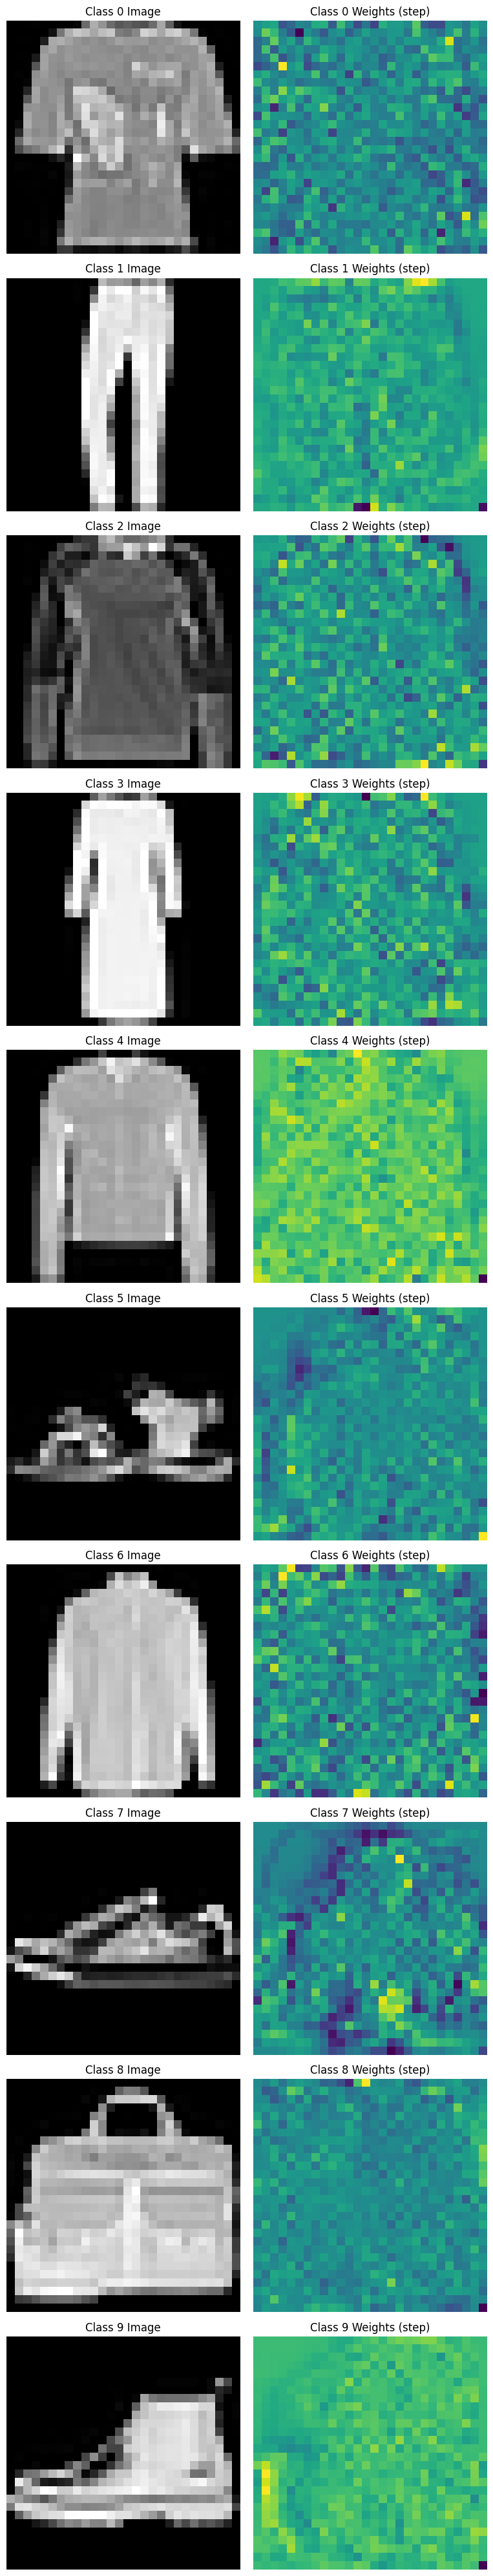

In [ ]:
# Plotting example image with weighted image

def plot_samples_and_weights(train_data, perceptrons_dict, activation):
    fig, axes = plt.subplots(10, 2, figsize=(8, 40))  # 10 rows, 2 columns (image | weights)
    
    labels = train_data[:, 0]
    inputs = train_data[:, 1:]
    
    for class_label in range(10):
        # Select the first example of the class from dataset
        sample_index = np.where(labels == class_label)[0][0]  # Find first occurrence
        sample_image = inputs[sample_index].reshape(28, 28)

        # Get the trained perceptrons weights for this class
        perceptron_weights = perceptrons_dict[class_label].weights
        weights_image = perceptron_weights[1:].reshape(28, 28)  # Ignore bias

        # Plot the sample image
        axes[class_label, 0].imshow(sample_image, cmap='gray')
        axes[class_label, 0].set_title(f"Class {class_label} Image")
        axes[class_label, 0].axis('off')

        # Plot the weight visualization
        axes[class_label, 1].imshow(weights_image, cmap = 'viridis')
        axes[class_label, 1].set_title(f"Class {class_label} Weights ({activation})")
        axes[class_label, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Plot images
plot_samples_and_weights(train_data, perceptrons_step_online, activation='step')